# **❤️ Heart Disease Prediction: Baseline to Best ML**
**Goal:** Predict whether a person has heart disease (`heart_disease` = 1) from health, lifestyle and ECG data.

**What this notebook covers**
1. Load & understand the data
2. Quick EDA (target balance, key features, correlations)
3. Preprocessing (scale numbers, encode categories) in a clean Pipeline
4. Train models from simple baseline to advanced and compare them
5. Tune the best model, check ROC curve, confusion matrix & feature importance
6. Conclusion

## **1. Import Libraries**

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
sns.set_style('whitegrid'); RS = 42

## **2. Load Data**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/heart-disease-prediction-dataset-2026/heart_disease_prediction_2026.csv')  
print(df.shape)
df.head()

(100000, 26)


,age,sex,bmi,region,income_level,smoking_status,alcohol_intake,physical_activity,diet_quality,sleep_hours,...,cholesterol,fasting_blood_sugar,max_heart_rate,resting_ecg,exercise_angina,st_depression,st_slope,avg_resting_hr,hrv_score,heart_disease
0,57,Male,27.1,Northeast,Middle,Never,Moderate,Light,7,5.7,...,204,0,195,Normal,0,0.9,Downsloping,61.8,19.9,0
1,40,Female,29.0,Northeast,Low,Never,Non-drinker,Sedentary,1,8.0,...,173,0,165,ST-T Abnormality,0,0.5,Downsloping,53.2,48.3,0
2,63,Female,40.1,Southeast,High,Never,Moderate,Sedentary,6,5.5,...,209,0,173,Normal,0,2.3,Downsloping,82.3,5.0,1
3,66,Female,35.5,West,Middle,Never,Heavy,Sedentary,10,7.4,...,187,0,144,Normal,0,1.3,Downsloping,71.1,38.3,1
4,29,Female,19.8,Northeast,High,Current,Non-drinker,Sedentary,8,8.3,...,247,0,170,ST-T Abnormality,0,0.4,Downsloping,74.1,49.4,0


In [3]:
df.info()
print('Missing values:', df.isna().sum().sum(), '| Duplicates:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   100000 non-null  int64  
 1   sex                   100000 non-null  object 
 2   bmi                   100000 non-null  float64
 3   region                100000 non-null  object 
 4   income_level          100000 non-null  object 
 5   smoking_status        100000 non-null  object 
 6   alcohol_intake        100000 non-null  object 
 7   physical_activity     100000 non-null  object 
 8   diet_quality          100000 non-null  int64  
 9   sleep_hours           100000 non-null  float64
 10  stress_level          100000 non-null  int64  
 11  diabetes              100000 non-null  int64  
 12  hypertension          100000 non-null  int64  
 13  family_history        100000 non-null  int64  
 14  previous_heart_event  100000 non-null  int64  
 15  r

## **3. Quick EDA**

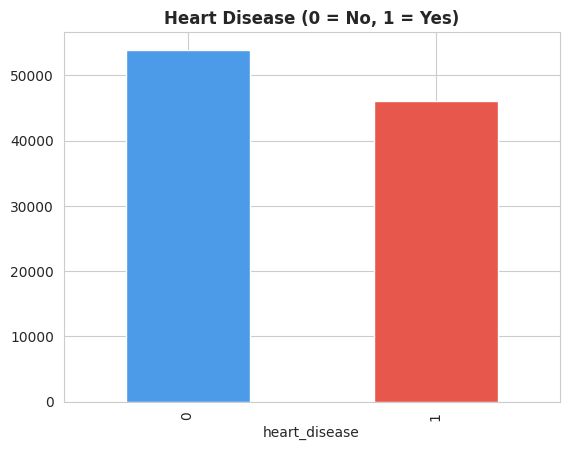

heart_disease
0    0.539
1    0.461
Name: proportion, dtype: float64


In [4]:
# Target balance
df['heart_disease'].value_counts().plot(kind='bar', color=['#4c9be8','#e8574c'])
plt.title('Heart Disease (0 = No, 1 = Yes)',fontweight='bold'); plt.show()
print(df['heart_disease'].value_counts(normalize=True).round(3))

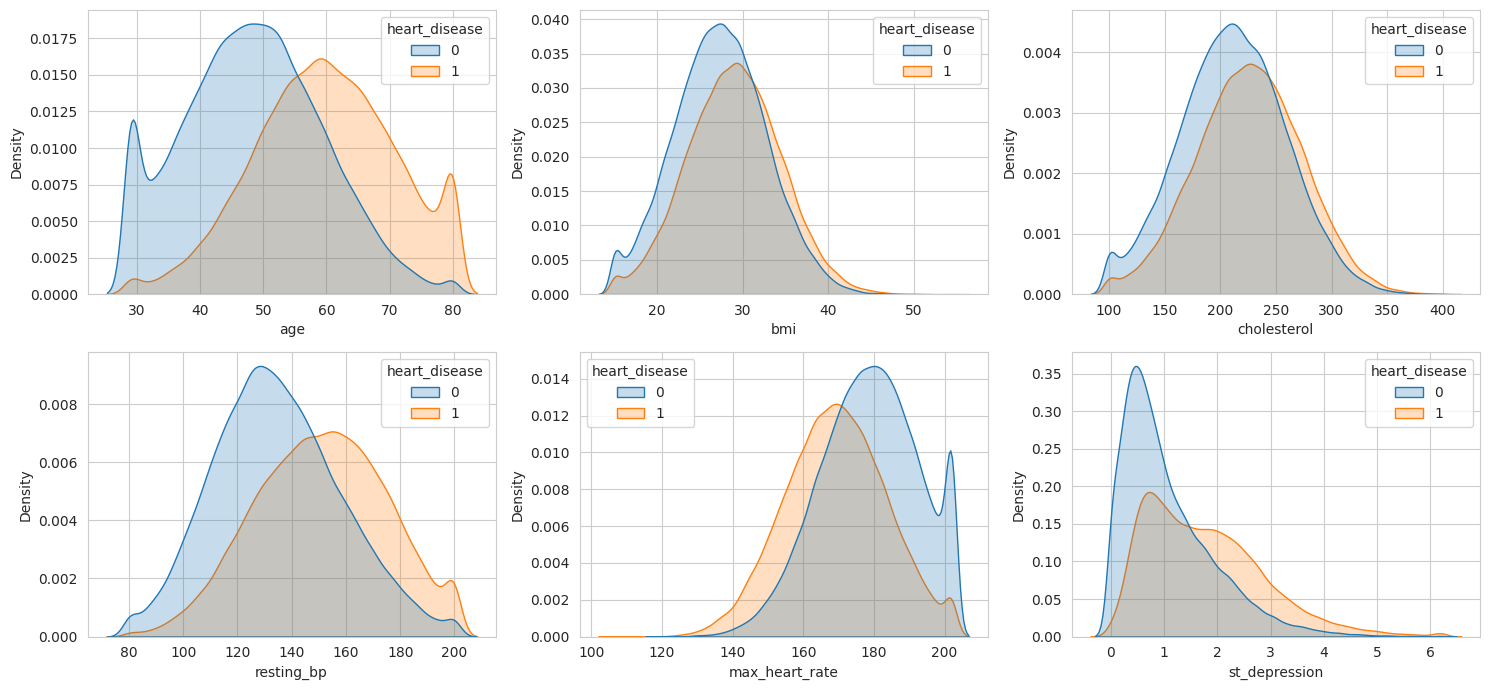

In [5]:
# Numeric features vs target
num_cols = df.select_dtypes('number').columns.drop('heart_disease')
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), ['age','bmi','cholesterol','resting_bp','max_heart_rate','st_depression']):
    sns.kdeplot(data=df, x=c, hue='heart_disease', fill=True, ax=a)
plt.tight_layout(); plt.show()

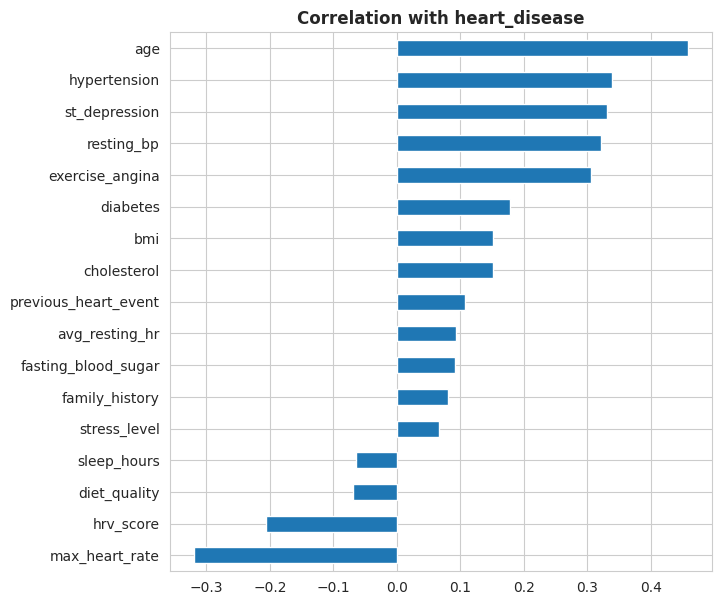

In [6]:
# Correlation of numeric features with the target
df[num_cols.tolist()+['heart_disease']].corr()['heart_disease'].drop('heart_disease').sort_values().plot(kind='barh', figsize=(7,7))
plt.title('Correlation with heart_disease',fontweight='bold'); plt.show()

## **4. Preprocessing**
Numbers are scaled, text columns are one-hot encoded. Everything lives inside a `Pipeline`, so the test data never leaks into training.

In [7]:
X = df.drop('heart_disease', axis=1); y = df['heart_disease']
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
num_cols = X.select_dtypes('number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)

prep = ColumnTransformer([('num', StandardScaler(), num_cols),
                          ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (80000, 25) | Test: (20000, 25)


## **5. Train & Compare Models (Baseline → Best)**

In [8]:
models = {
    'Dummy (baseline)'   : DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, random_state=RS),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=RS),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=RS),
}
rows, fitted = [], {}
for name, m in models.items():
    pipe = Pipeline([('prep', prep), ('model', m)]).fit(X_train, y_train)
    p = pipe.predict(X_test); pr = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    rows.append([name, accuracy_score(y_test, p), f1_score(y_test, p), roc_auc_score(y_test, pr)])
results = pd.DataFrame(rows, columns=['Model','Accuracy','F1','ROC-AUC']).sort_values('ROC-AUC', ascending=False).round(4)
results

,Model,Accuracy,F1,ROC-AUC
1,Logistic Regression,0.7742,0.7497,0.8546
4,Hist Gradient Boosting,0.7719,0.7487,0.8511
3,Random Forest,0.7634,0.7345,0.8429
2,Decision Tree,0.7360,0.7092,0.8087
0,Dummy (baseline),0.5392,0.0000,0.5000


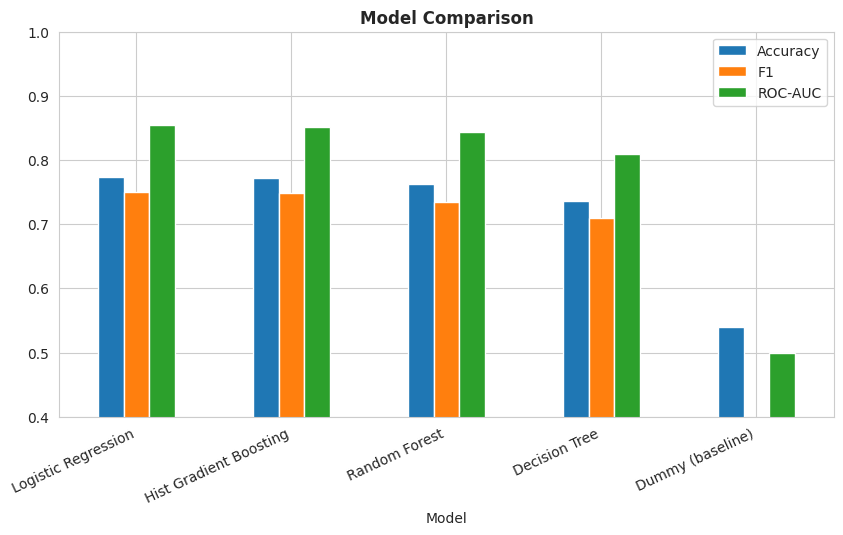

In [9]:
results.set_index('Model')[['Accuracy','F1','ROC-AUC']].plot(kind='bar', figsize=(10,5), ylim=(0.4,1))
plt.title('Model Comparison',fontweight='bold'); plt.xticks(rotation=25, ha='right'); plt.show()

## **6. Tune the Best Model**
We tune Gradient Boosting with a small randomized search and 3-fold cross-validation.

In [10]:
base = Pipeline([('prep', prep), ('model', HistGradientBoostingClassifier(random_state=RS))])
params = {'model__learning_rate':[0.03,0.05,0.1],
          'model__max_depth':[3,5,None],
          'model__max_iter':[200,300,500],
          'model__l2_regularization':[0,1,5]}
search = RandomizedSearchCV(base, params, n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=RS)
search.fit(X_train, y_train)
best = search.best_estimator_
print('Best params:', search.best_params_)
print('CV ROC-AUC :', round(search.best_score_, 4))

Best params: {'model__max_iter': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__l2_regularization': 0}
CV ROC-AUC : 0.8504


## **7. Final Evaluation on Unseen Test Data**

In [11]:
pred = best.predict(X_test); proba = best.predict_proba(X_test)[:, 1]
print('Accuracy :', round(accuracy_score(y_test, pred), 4))
print('F1 score :', round(f1_score(y_test, pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, proba), 4))
print(classification_report(y_test, pred))

Accuracy : 0.7743
F1 score : 0.75
ROC-AUC  : 0.8526
              precision    recall  f1-score   support

           0       0.78      0.81      0.79     10784
           1       0.77      0.73      0.75      9216

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



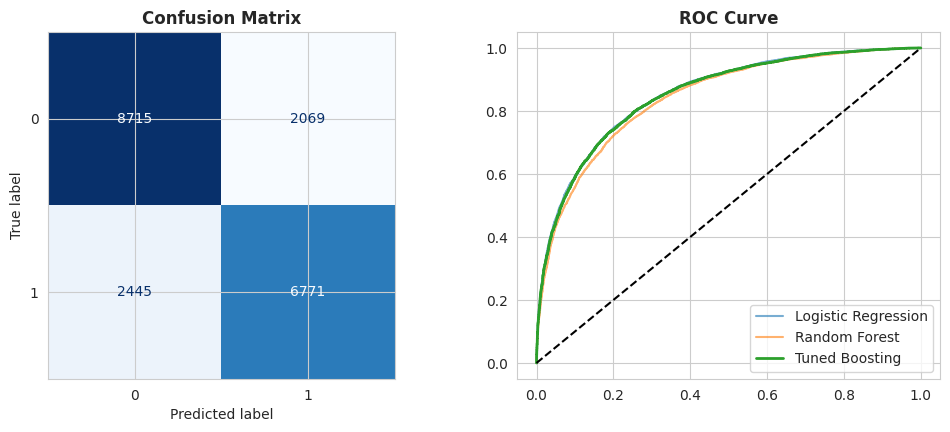

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Confusion Matrix',fontweight='bold')
for n in ['Logistic Regression','Random Forest']:
    f, t, _ = roc_curve(y_test, fitted[n].predict_proba(X_test)[:,1]); ax[1].plot(f, t, label=n, alpha=.6)
f, t, _ = roc_curve(y_test, proba); ax[1].plot(f, t, label='Tuned Boosting', lw=2)
ax[1].plot([0,1],[0,1],'k--'); ax[1].set_title('ROC Curve',fontweight='bold'); ax[1].legend(); plt.show()

## **8. Feature Importance**
Which features matter most? (Permutation importance on a test sample)

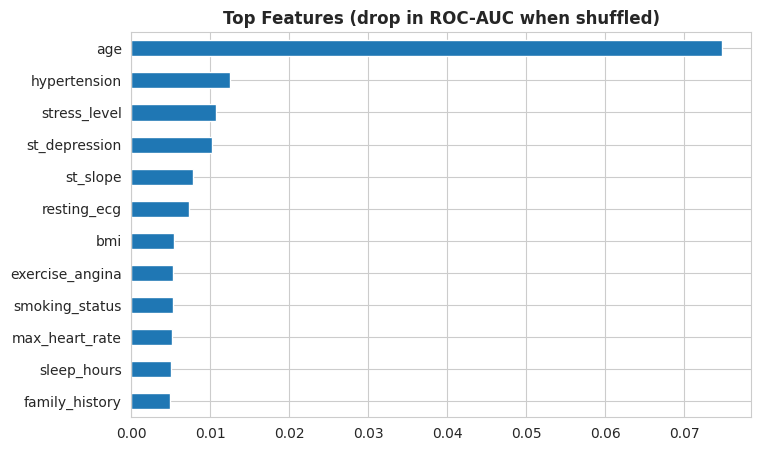

In [13]:
from sklearn.inspection import permutation_importance
s = X_test.sample(5000, random_state=RS)
imp = permutation_importance(best, s, y_test.loc[s.index], scoring='roc_auc', n_repeats=3, random_state=RS, n_jobs=-1)
pd.Series(imp.importances_mean, index=X.columns).sort_values().tail(12).plot(kind='barh', figsize=(8,5))
plt.title('Top Features (drop in ROC-AUC when shuffled)',fontweight='bold'); plt.show()

## **9. Conclusion**
**Results (20% unseen test set, 100,000 patients)**

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Dummy baseline | 0.539 | 0.000 | 0.500 |
| Decision Tree | 0.736 | 0.709 | 0.809 |
| Random Forest | 0.763 | 0.735 | 0.843 |
| Logistic Regression | 0.774 | 0.750 | 0.855 |
| Hist Gradient Boosting | 0.772 | 0.749 | 0.851 |
| **Tuned Gradient Boosting** | **0.774** | **0.750** | **0.853** |

**Key takeaways**
- Every real model beats the 54% dummy baseline by a wide margin (~+23 points accuracy).
- Simple Logistic Regression is as good as the complex boosting model, so the signal in this data is mostly **linear**. More complexity gave no extra gain (we also checked interaction features: same ~77.5%).
- The model catches about 73% of true heart-disease cases (recall) with 77% precision.
- Check the feature-importance chart above to see which health factors drive the prediction most.

**Next steps:** try threshold tuning for higher recall (important in medicine), add XGBoost/LightGBM, and use SHAP for deeper explanations.

